In [50]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import random
import tempfile
import gzip
import pylhe
import math
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D
from auxPlots import  xSecTest, getInfoSMS
from aux import getLHEevents, getDistributions, getInfo, getInfoSummary
from matplotlib.ticker import FixedLocator
from scipy import stats

pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

In [2]:
def selectColor(model, process):
    if model == 'VLF EFT':
        return sns.color_palette('Paired')[0]
    elif model == '1-loop VLF':
        return sns.color_palette('Paired')[1]
    elif model == 'Scalar EFT':
        return sns.color_palette('Paired')[2]
    elif model == 'SM':
        return sns.color_palette('Paired')[9]
    else:
        return sns.color_palette('Paired')[3]

In [3]:
def selectColor(model, process):
    if model == 'VLF EFT':
        return sns.color_palette('Paired')[0]
    elif model == '1-loop VLF':
        return sns.color_palette('Paired')[1]
    elif model == 'Scalar EFT':
        return sns.color_palette('Paired')[2]
    elif model == 'SM':
        return sns.color_palette('Paired')[9]
    else:
        return sns.color_palette('Paired')[3]

In [4]:
def get_color_by_mass(model, mass):
    mPsiT, mSDM = mass
    
    # --- COLORS FOR VECTOR-LIKE FERMION (VLF) ---
    # Using a progression from bright blue -> dark blue -> purple
    if '1-loop VLF' in model:
        if mPsiT == 500.0 and mSDM == 375.0:
            return 'deepskyblue'   # Bright, distinct blue
        elif mPsiT == 500.0 and mSDM == 475.0:
            return 'dodgerblue'         # Standard pure blue
        elif mPsiT == 600.0 and mSDM == 475.0:
            return 'blue'         # Very dark blue
        elif mPsiT == 1500.0 and mSDM == 1425.0:
            return 'navy'   # Purple-ish blue to separate high mass
        else:
            return 'cornflowerblue' # Fallback

    # --- COLORS FOR SCALAR ---
    # Using a progression from bright green -> dark green -> teal
    elif '1-loop Scalar' in model:
        if mPsiT == 500.0 and mSDM == 375.0:
            return 'chartreuse'    # Bright, distinct green
        elif mPsiT == 500.0 and mSDM == 475.0:
            return 'limegreen'  # Standard deep green
        elif mPsiT == 600.0 and mSDM == 475.0:
            return 'forestgreen'    # Very dark green
        elif mPsiT == 1500.0 and mSDM == 1425.0:
            return 'darkgreen'         # Blue-green to separate high mass
        else:
            return 'mediumseagreen' # Fallback
    elif 'Z prime' in model:
        return sns.color_palette('Paired')[5]

    # --- DEFAULT ---
    else:
        return 'black'

In [5]:
files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/*/bias_article/*900*.npz'))
data = []
for f in files:
    aux = np.load(f, allow_pickle = True)
    data.append(aux)
print(data)    
data = sorted(data, key=lambda d: (d['mass_params'][0], d['mass_params'][1]))

[NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/gg2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/qq2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz' with keys: mTT, pT1, pT2, deltaPhi, weights...]


In [9]:
select = []
for d in data:
    if d['mass_params'][0] == 1000.0 and d['mass_params'][1] == 900.0:
        select.append(d)

print(select)

[NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/gg2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/qq2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz' with keys: mTT, pT1, pT2, deltaPhi, weights...]


In [20]:
pure_BSM_f  = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/Scalar_ff/pp2ttbar_gs4_ydm4/bias_test_pureBSM_1000_900/*.npz'))
pBSM = np.load(pure_BSM_f[0], allow_pickle = True)
    

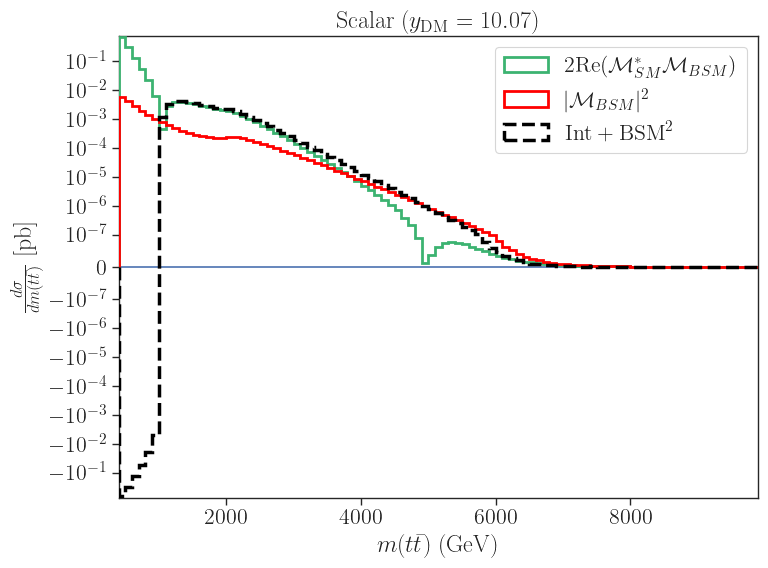

In [61]:
################
# SM err (%)   #
################

lum = 1e-3 # fb^-1

# -------------------------------------------------------------
# LUMINOSITY SCALING FACTOR
# Assuming your MC weights are in picobarns (pb), 1 pb = 1000 fb.
# If your weights are already in fb, change this to: lum_scale = lum
# -------------------------------------------------------------
lum_scale = lum * 1000.0 

sm_err = 0.05

# BSM masses and couplings
mPsiT, mSDM = select[0]['mass_params']
yDM = select[0]['ydm']

# --- Setup and Binning ---
fig, ax = plt.subplots(figsize=(8, 6))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=0.9)

if mPsiT < 600:
    bins = np.arange(400., 3000., 50.)
elif mPsiT < 1000:
    bins = np.arange(500., 4000., 75.)
else:
    bins = np.arange(400., 10000., 100.)

x = (bins[:-1] + bins[1:]) / 2.0
bin_widths = np.diff(bins)

##############
# Main Plot  #
##############

pmodels = []
bsm_hists, bsm_errs, bsm_labels, bsm_colors = [], [], [], []

# Plotting the NLO BSM Data (Summing qq + gg for each model)
y_DM = {'1-loop VLF': 6.0, '1-loop Scalar':  1.006886e+01}
#y_DM = {'1-loop VLF': 1.0, '1-loop Scalar': 3.06822e+00}

# Initialize a variable to hold the interference array for the sum
h_interference = None

for j in range(0, len(select), 2):
    d = select[j]
    d_next = select[j+1]

    process = r'$p p \to t \bar{t}$'
    model = d['model']
    model_raw = d['model']
    model_name = str(np.atleast_1d(model_raw)[0])
    display_name = model_name.replace('1-loop ', '')
    pmodels.append(r'%s (%s)' % (process, display_name))
    label = pmodels[-1]

    color = get_color_by_mass(model, (mPsiT, mSDM))

    h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
    hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)

    h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
    hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
    
    scale_weight_int = y_DM.get(model_name, 1.0)**2 

    # Scale by luminosity
    h_bsm_total = (h1 + h2) * scale_weight_int * lum_scale
    hErr_bsm_total_sq = (hErr1_sq + hErr2_sq) * (scale_weight_int**2) * (lum_scale**2)

    integral_bsm = np.sum(h_bsm_total)
    h_bsm = h_bsm_total
    hErr_bsm = np.sqrt(hErr_bsm_total_sq)

    bsm_hists.append(h_bsm)
    bsm_errs.append(hErr_bsm)
    bsm_labels.append(label)
    bsm_colors.append(color)
    
    # Save this for the sum calculation later
    h_interference = h_bsm

    ax.hist(
        bins[:-1], weights=np.abs(h_bsm), label=r'$2\mathrm{Re}(\mathcal{M}_{SM}^* \mathcal{M}_{BSM})$ ', bins=bins,
        color=color, alpha=1.0, histtype='step', 
        linewidth=2, fill=False, zorder=3
    )

# -------------------------------------------------------------
# Pure BSM Calculation
# -------------------------------------------------------------
h_pure, _ = np.histogram(pBSM['mTT'], bins=bins, weights=pBSM['weights'])
hErr_sq, _ = np.histogram(pBSM['mTT'], bins=bins, weights=np.array(pBSM['weights'])**2)

scale_weight_pure = y_DM.get('1-loop Scalar', 1.0)**4 

# FIXED: Added lum_scale here to correctly match the interference scale!
h_pure = h_pure * scale_weight_pure * lum_scale 

ax.hist(
    bins[:-1], weights=np.abs(h_pure), label=r'$\vert \mathcal{M}_{BSM}\vert^2$ ', bins=bins,
    color='red', alpha=1.0, histtype='step', 
    linewidth=2, fill=False, zorder=3
)

# -------------------------------------------------------------
# Sum of Interference + Pure BSM
# -------------------------------------------------------------
if h_interference is not None:
    h_sum = h_interference + h_pure
    
    ax.hist(
        bins[:-1], weights=h_sum, label=r'$\mathrm{Int} + \mathrm{BSM}^2$', bins=bins,
        color='black', linestyle='--', alpha=1.0, histtype='step', 
        linewidth=2.5, fill=False, zorder=4
    )
ax.axhline(y=0)
ax.set_yscale('symlog',linthresh = 1e-7)

# Axes and formatting
ax.set_ylabel(r'$\frac{d\sigma}{dm(t\bar{t})}$ [pb]')
ax.set_xlabel(r'$m(t\bar{t})$ (GeV)')
ax.set_xlim(bins.min(), bins.max())
ax.legend()

# Fixed Title string formatting
ax.set_title(rf"Scalar ($y_{{\mathrm{{DM}}}}={y_DM.get('1-loop Scalar', 1.0):.2f}$)")

plt.tight_layout()
#plt.savefig('Dists_comparison_interference.png')
plt.show()

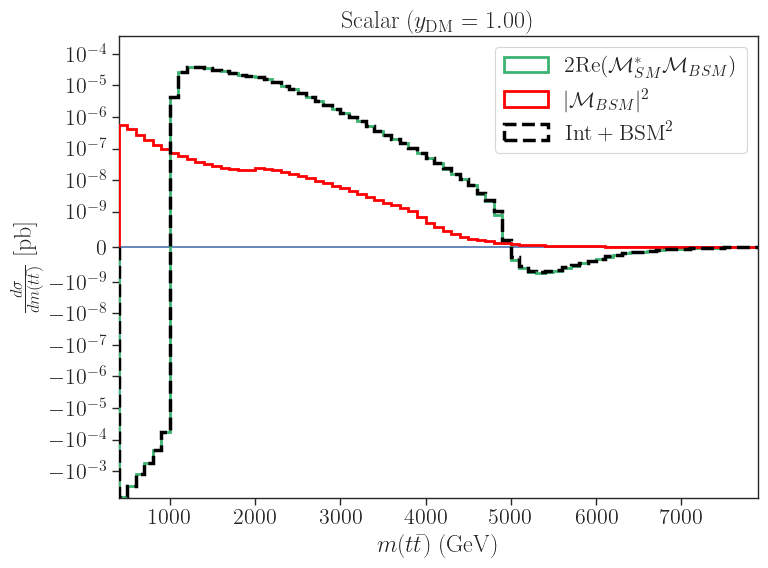

In [73]:
################
# SM err (%)   #
################

lum = 1e-3 # fb^-1

# -------------------------------------------------------------
# LUMINOSITY SCALING FACTOR
# Assuming your MC weights are in picobarns (pb), 1 pb = 1000 fb.
# If your weights are already in fb, change this to: lum_scale = lum
# -------------------------------------------------------------
lum_scale = lum * 1000.0 

sm_err = 0.05

# BSM masses and couplings
mPsiT, mSDM = select[0]['mass_params']
yDM = select[0]['ydm']

# --- Setup and Binning ---
fig, ax = plt.subplots(figsize=(8, 6))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=0.9)

if mPsiT < 600:
    bins = np.arange(400., 3000., 50.)
elif mPsiT < 1000:
    bins = np.arange(500., 4000., 75.)
else:
    bins = np.arange(400., 8000., 100.)

x = (bins[:-1] + bins[1:]) / 2.0
bin_widths = np.diff(bins)

##############
# Main Plot  #
##############

pmodels = []
bsm_hists, bsm_errs, bsm_labels, bsm_colors = [], [], [], []

# Plotting the NLO BSM Data (Summing qq + gg for each model)
y_DM = {'1-loop VLF': 6.0, '1-loop Scalar':  1.0}#1.006886e+01}
#y_DM = {'1-loop VLF': 1.0, '1-loop Scalar': 3.06822e+00}

# Initialize a variable to hold the interference array for the sum
h_interference = None

for j in range(0, len(select), 2):
    d = select[j]
    d_next = select[j+1]

    process = r'$p p \to t \bar{t}$'
    model = d['model']
    model_raw = d['model']
    model_name = str(np.atleast_1d(model_raw)[0])
    display_name = model_name.replace('1-loop ', '')
    pmodels.append(r'%s (%s)' % (process, display_name))
    label = pmodels[-1]

    color = get_color_by_mass(model, (mPsiT, mSDM))

    h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
    hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)

    h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
    hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
    
    scale_weight_int = y_DM.get(model_name, 1.0)**2 

    # Scale by luminosity
    h_bsm_total = (h1 + h2) * scale_weight_int * lum_scale
    hErr_bsm_total_sq = (hErr1_sq + hErr2_sq) * (scale_weight_int**2) * (lum_scale**2)

    integral_bsm = np.sum(h_bsm_total)
    h_bsm = h_bsm_total
    hErr_bsm = np.sqrt(hErr_bsm_total_sq)

    bsm_hists.append(h_bsm)
    bsm_errs.append(hErr_bsm)
    bsm_labels.append(label)
    bsm_colors.append(color)
    
    # Save this for the sum calculation later
    h_interference = h_bsm

    ax.hist(
        bins[:-1], weights=h_bsm, label=r'$2\mathrm{Re}(\mathcal{M}_{SM}^* \mathcal{M}_{BSM})$ ', bins=bins,
        color=color, alpha=1.0, histtype='step', 
        linewidth=2, fill=False, zorder=3
    )

# -------------------------------------------------------------
# Pure BSM Calculation
# -------------------------------------------------------------
h_pure, _ = np.histogram(pBSM['mTT'], bins=bins, weights=pBSM['weights'])
hErr_sq, _ = np.histogram(pBSM['mTT'], bins=bins, weights=np.array(pBSM['weights'])**2)

scale_weight_pure = y_DM.get('1-loop Scalar', 1.0)**4 

# FIXED: Added lum_scale here to correctly match the interference scale!
h_pure = h_pure * scale_weight_pure * lum_scale 

ax.hist(
    bins[:-1], weights=h_pure, label=r'$\vert \mathcal{M}_{BSM}\vert^2$ ', bins=bins,
    color='red', alpha=1.0, histtype='step', 
    linewidth=2, fill=False, zorder=3
)

# -------------------------------------------------------------
# Sum of Interference + Pure BSM
# -------------------------------------------------------------
if h_interference is not None:
    h_sum = h_interference + h_pure
    
    ax.hist(
        bins[:-1], weights=h_sum, label=r'$\mathrm{Int} + \mathrm{BSM}^2$', bins=bins,
        color='black', linestyle='--', alpha=1.0, histtype='step', 
        linewidth=2.5, fill=False, zorder=4
    )
ax.axhline(y=0)
ax.set_yscale('symlog',linthresh = 1e-9)

# Axes and formatting
ax.set_ylabel(r'$\frac{d\sigma}{dm(t\bar{t})}$ [pb]')
ax.set_xlabel(r'$m(t\bar{t})$ (GeV)')
ax.set_xlim(bins.min(), bins.max())
ax.legend()

# Fixed Title string formatting
ax.set_title(rf"Scalar ($y_{{\mathrm{{DM}}}}={y_DM.get('1-loop Scalar', 1.0):.2f}$)")

plt.tight_layout()
#plt.savefig('Dists_comparison_interference.png')
plt.show()